# Exploratory Data Analysis on UN Data on Refugees
The aim of this projects is to go througn the steps Exploratory Data analysis and, show my thought process in handling such task and share insights.

**Dataset** : "UN_refugee_data.xlsx"

**Source** : https://data.un.org/Data.aspx?q=refugee&d=UNHCR&f=indID%3aType-Ref

## About Dataset
This dataset provides annual statistics on refugees and refugee-like populations across the globe, compiled by the UNHCR (United Nations High Commissioner for Refugees). It includes information on countries of origin and asylum, the number of individuals displaced, those assisted by UNHCR, and the administrative costs borne by host countries. The dataset serves as a crucial resource for understanding global displacement trends, humanitarian support, and policy planning.

### Data Dictionary / Feature Description 
- **Country or territory of asylum or residence** : This is the country where the displaced individuals have sought refuge or are currently residing. This includes both recognized refugees and others in refugee-like situations.
- **Country or territory of origin** : The country from which the individuals fled due to conflict, persecution, or other crises.
- **Year**: The reporting year for the data, indicating the time period the data covers.
- **Refugees**: The number of individuals who have been formally recognized as refugees under international or national legal frameworks.
- **Refugees assisted by UNHCR**: The subset of refugees receiving direct or indirect support (e.g., shelter, food, legal aid) from the United Nations High Commissioner for Refugees (UNHCR).
- **Total refugees and people in refugee-like situations** : The combined total of recognized refugees and those in similar circumstances who may not have official refugee status but face the same vulnerabilities.
- **Total refugees and people in refugee-like situations assisted by UNHCR** : The number of individuals in the above category who are supported by UNHCR services or interventions.	
- **Total Administrative Cost for Host Country** : The estimated cost incurred by the host country in providing services, infrastructure, and administrative support to refugees during the reported year.

## EDA Guiding Questions
1. Which country have hosted the largest number of refugees over time?
2. Is there a relationship between the refugees with UNHCR assisstance and the total refugees?
3. Which countries are the top sources of refugees globally?
4. which countries have the highest Admistrative cost?
5. How does the refugees assisstance vary across different hosted countries?
6. How has the number of refugees changed over time?





### Load and Inspect the Data


In [ ]:
# Install necessary packages
%pip install -r requirements.txt

In [2]:
# Import libraries
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# import plotly.graph_objects as go

%matplotlib inline

# suppress future warnings
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
# Load the dataset
df = pd.read_excel('./Data/UN_refugee_data.xlsx')
df.head()

,Unnamed: 0,Country or territory of asylum or residence,Country or territory of origin,Year,Refugees*,Refugees assisted by UNHCR,Total refugees and people in refugee-like situations**,Total refugees and people in refugee-like situations assisted by UNHCR,Total Administrative Cost for Host Country
0,NaN,Afghanistan,Iran (Islamic Rep. of),2021,38,38,38,38,760000
1,NaN,Afghanistan,Pakistan,2021,72188,123,72188,123,1443760000
2,NaN,Albania,China,2021,14,0,14,0,280000
3,NaN,Albania,Egypt,2021,5,0,5,0,100000
4,NaN,Albania,Iraq,2021,5,0,5,0,100000


In [ ]:
# Check the shape of the DataFrame
df.shape

(4266, 9)

In [ ]:
# Check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4266 entries, 0 to 4265
Data columns (total 9 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   Unnamed: 0                                                              0 non-null      float64
 1   Country or territory of asylum or residence                             4266 non-null   object 
 2   Country or territory of origin                                          4266 non-null   object 
 3   Year                                                                    4266 non-null   int64  
 4   Refugees*                                                               4266 non-null   object 
 5   Refugees assisted by UNHCR                                              4266 non-null   int64  
 6   Total refugees and people in refugee-like situations**                  4266 non-

In [ ]:
# Get summary statistics
df.describe(include='number')

,Unnamed: 0,Year,Refugees assisted by UNHCR,Total refugees and people in refugee-like situations**,Total refugees and people in refugee-like situations assisted by UNHCR
count,0.0,4266.0,4.266000e+03,4.266000e+03,4.266000e+03
mean,NaN,2021.0,2.432079e+03,4.853689e+03,2.450383e+03
std,NaN,0.0,3.780646e+04,7.080561e+04,3.782750e+04
min,NaN,2021.0,0.000000e+00,5.000000e+00,0.000000e+00
25%,NaN,2021.0,0.000000e+00,7.000000e+00,0.000000e+00
50%,NaN,2021.0,0.000000e+00,2.400000e+01,0.000000e+00
75%,NaN,2021.0,5.000000e+00,1.687500e+02,5.000000e+00
max,NaN,2021.0,1.438020e+06,3.685839e+06,1.438020e+06


In [ ]:
# Get summary statistics for categorical columns
df.describe(include='object')

,Country or territory of asylum or residence,Country or territory of origin,Refugees*,Total Administrative Cost for Host Country
count,4266,4266,4266,4266
unique,163,187,1011,1011
top,United States of America,Syrian Arab Rep.,5,100000
freq,168,113,823,823


### Observations
- UN refugee dataset contains 4266 records and 9 features.
- Unnamed:0 col has no records
- The colums of the datasect don't have an appropriate naming convesions
- "Year","Refugees*" and "Total Administrative Cost for Host Country" have incorrect data types
- Country of asylum and country of orign have 163 and 187 unique record respectively

## Clean Data

In [9]:
# Drop columns with missing values
df.dropna(axis=1, inplace=True)

In [10]:
df.columns

Index(['Country or territory of asylum or residence',
       'Country or territory of origin', 'Year', 'Refugees*',
       'Refugees assisted by UNHCR',
       'Total refugees and people in refugee-like situations**',
       'Total refugees and people in refugee-like situations assisted by UNHCR',
       'Total Administrative Cost for Host Country'],
      dtype='object')

In [11]:
# Convert "Year" column to datetime
df["Year"] = pd.to_datetime(df["Year"], format="%Y")

In [12]:
df['Refugees*'].isna().value_counts()

Refugees*
False    4266
Name: count, dtype: int64

In [13]:
df['Refugees*'].where(df['Refugees*'] == '""').value_counts()

Series([], Name: count, dtype: int64)

In [14]:
# Replace blank strings and non-numeric values with NaN, then fill with 0 or appropriate value
df['Refugees*'] = pd.to_numeric(df['Refugees*'], errors='coerce').fillna(0).astype(int)
df['Total Administrative Cost for Host Country'] = pd.to_numeric(df['Total Administrative Cost for Host Country'], errors='coerce').fillna(0).astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4266 entries, 0 to 4265
Data columns (total 8 columns):
 #   Column                                                                  Non-Null Count  Dtype         
---  ------                                                                  --------------  -----         
 0   Country or territory of asylum or residence                             4266 non-null   object        
 1   Country or territory of origin                                          4266 non-null   object        
 2   Year                                                                    4266 non-null   datetime64[ns]
 3   Refugees*                                                               4266 non-null   int64         
 4   Refugees assisted by UNHCR                                              4266 non-null   int64         
 5   Total refugees and people in refugee-like situations**                  4266 non-null   int64         
 6   Total refugees and people

In [16]:
df=df.set_axis(
    [
        'country_asylum', 'country_origin', 'year', 'num_refugees',
        'refugees_assisted_by_UNHCR', 'total_refugees', 'total_refugees_asylum',
        'host_country_administration_cost'
    ], axis=1)

## Univariate and Bivariate Exploration

In [17]:
df['country_asylum'].value_counts().head(10)

country_asylum
United States of America    168
Canada                      152
Germany                     150
United Kingdom              132
France                      131
Sweden                      106
Switzerland                 105
Australia                    97
Belgium                      96
Netherlands                  91
Name: count, dtype: int64

In [18]:
df['country_origin'].value_counts().head(10)

country_origin
Syrian Arab Rep.          113
Somalia                    97
Iraq                       94
Dem. Rep. of the Congo     92
Sudan                      91
Afghanistan                87
Yemen                      85
Eritrea                    82
Iran (Islamic Rep. of)     81
Turkey                     79
Name: count, dtype: int64

In [19]:
df['year'].value_counts().head(10)

year
2021-01-01    4266
Name: count, dtype: int64

In [67]:
# Calculate correlation matrix for numeric features
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# show the full correlation matrix
print("Correlation matrix:")
display(corr_matrix)

# list top correlated feature pairs (excluding self-correlations)
corr_pairs = (
    corr_matrix.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr'})
)
corr_pairs = corr_pairs[corr_pairs['feature_1'] != corr_pairs['feature_2']]
corr_pairs['abs_corr'] = corr_pairs['corr'].abs()
corr_pairs = corr_pairs.sort_values('abs_corr', ascending=False).drop_duplicates(subset=['abs_corr'])

print("\nTop correlated feature pairs:")
display(corr_pairs.head(10))

Correlation matrix:


,num_refugees,refugees_assisted_by_UNHCR,total_refugees,total_refugees_asylum,host_country_administration_cost
num_refugees,1.000000,0.544428,0.999827,0.544280,1.000000
refugees_assisted_by_UNHCR,0.544428,1.000000,0.544439,0.999762,0.544428
total_refugees,0.999827,0.544439,1.000000,0.544570,0.999827
total_refugees_asylum,0.544280,0.999762,0.544570,1.000000,0.544280
host_country_administration_cost,1.000000,0.544428,0.999827,0.544280,1.000000



Top correlated feature pairs:


,feature_1,feature_2,corr,abs_corr
4,num_refugees,host_country_administration_cost,1.000000,1.000000
10,total_refugees,num_refugees,0.999827,0.999827
22,host_country_administration_cost,total_refugees,0.999827,0.999827
8,refugees_assisted_by_UNHCR,total_refugees_asylum,0.999762,0.999762
17,total_refugees_asylum,total_refugees,0.544570,0.544570
11,total_refugees,refugees_assisted_by_UNHCR,0.544439,0.544439
5,refugees_assisted_by_UNHCR,num_refugees,0.544428,0.544428
21,host_country_administration_cost,refugees_assisted_by_UNHCR,0.544428,0.544428
3,num_refugees,total_refugees_asylum,0.544280,0.544280
19,total_refugees_asylum,host_country_administration_cost,0.544280,0.544280


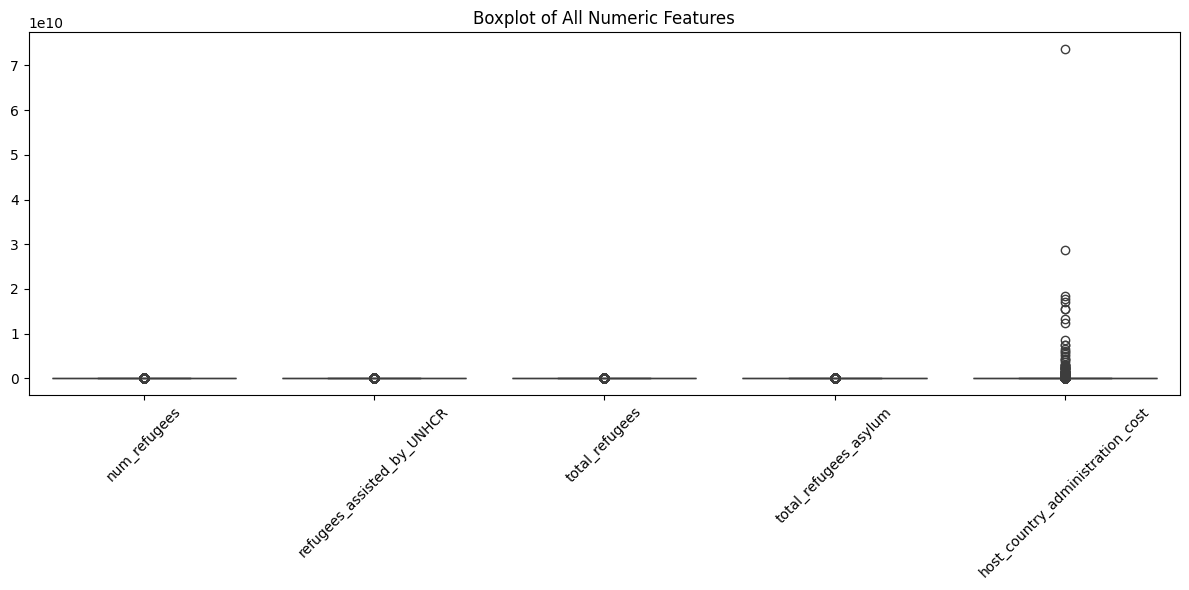

In [72]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_df)

# Add title and rotate x-axis labels if needed
plt.title('Boxplot of All Numeric Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


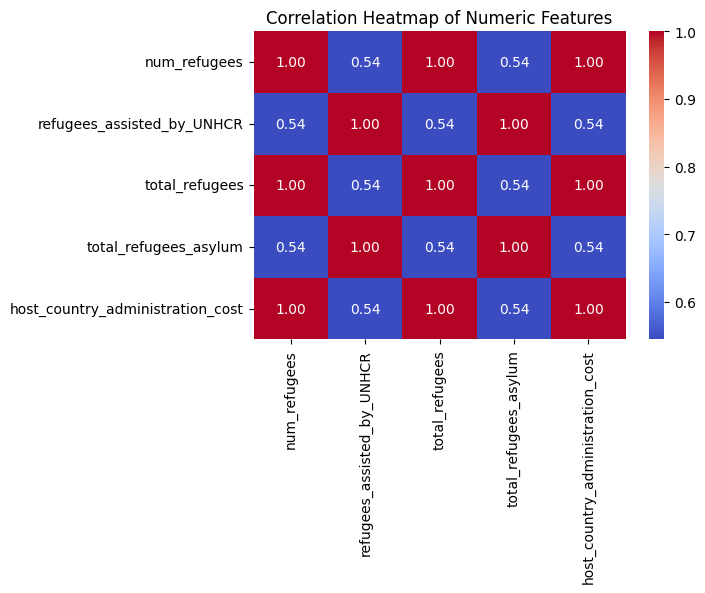

In [ ]:
# Correlation heatmap of numeric features
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

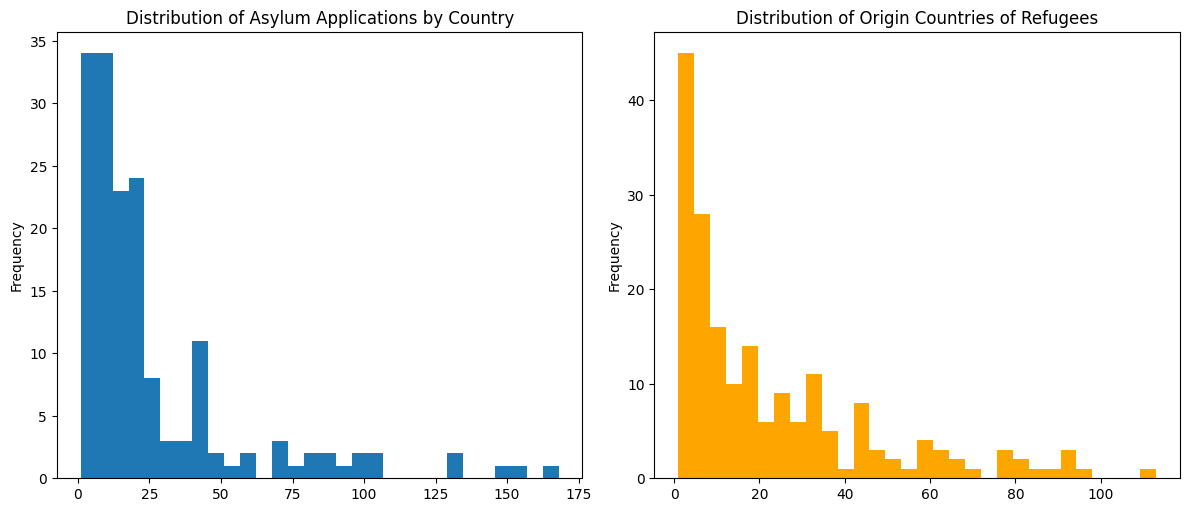

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['country_asylum'].value_counts().plot.hist(ax=axes[0], bins=30,)
df['country_origin'].value_counts().plot.hist(ax=axes[1], color='orange', bins=30)
plt.tight_layout()
axes[0].set_title('Distribution of Asylum Applications by Country')
axes[1].set_title('Distribution of Origin Countries of Refugees')
plt.show()

# Findings

- United States and Egypt appears to be among the top destinations for asylum seekers.
- Most of the recorded refugees originate from the Syrian Arab Republic and Somalia.
- the data under review is for 2021 only
- The distribution of asylum applications across countries is negatively skewed, indicating that most countries in the dataset have a high number of recorded applications, while only a few have relatively low counts.
- There was perfect collection among the features, suggesting that they might be measuring the same underlying situation or instance or derives from on another.
- "host_country_administration_cost" has a moderate positive relationship with the other features, indicating that as refugee numbers increase, administrative costs tend to rise—but not perfectly. This may imply that other factors (like efficiency, policy, or external aid) may influence costs beyond just refugee volume.

## Visualize data

<Axes: title={'center': 'Top 10 Countries Receiving Asylum Applications'}, xlabel='country_asylum'>

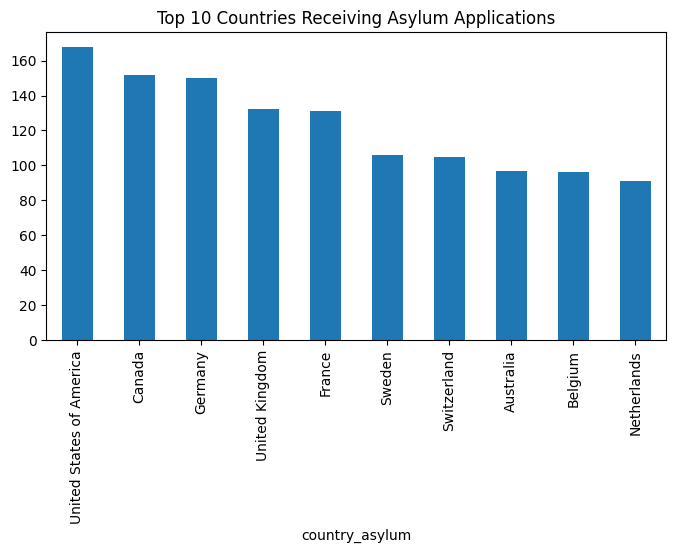

In [ ]:

top_10 = df['country_asylum'].value_counts().nlargest(10)
top_10.plot(kind='bar', figsize=(8, 4), title='Top 10 Countries Receiving Asylum Applications')




In [22]:
country_counts = df['country_asylum'].value_counts().reset_index()
country_counts.columns = ['country', 'count']
fig = px.choropleth(country_counts, locations='country', locationmode='country names',
                    color='count', title='Global Distribution of Asylum Applications')
fig.show()


In [44]:
# Top 10 countries receiving asylum applications based on total number of refugees
top_10_countries = df.groupby('country_asylum')['num_refugees'].sum().reset_index().sort_values(by='num_refugees', ascending=False).head(10)
top_10_countries

,country_asylum,num_refugees
148,Turkey,3696831
151,Uganda,1475311
113,Pakistan,1438523
58,Germany,1235160
138,Sudan,1068339
11,Bangladesh,889775
83,Lebanon,856758
70,Iran (Islamic Rep. of),800025
51,Ethiopia,782896
77,Jordan,708308


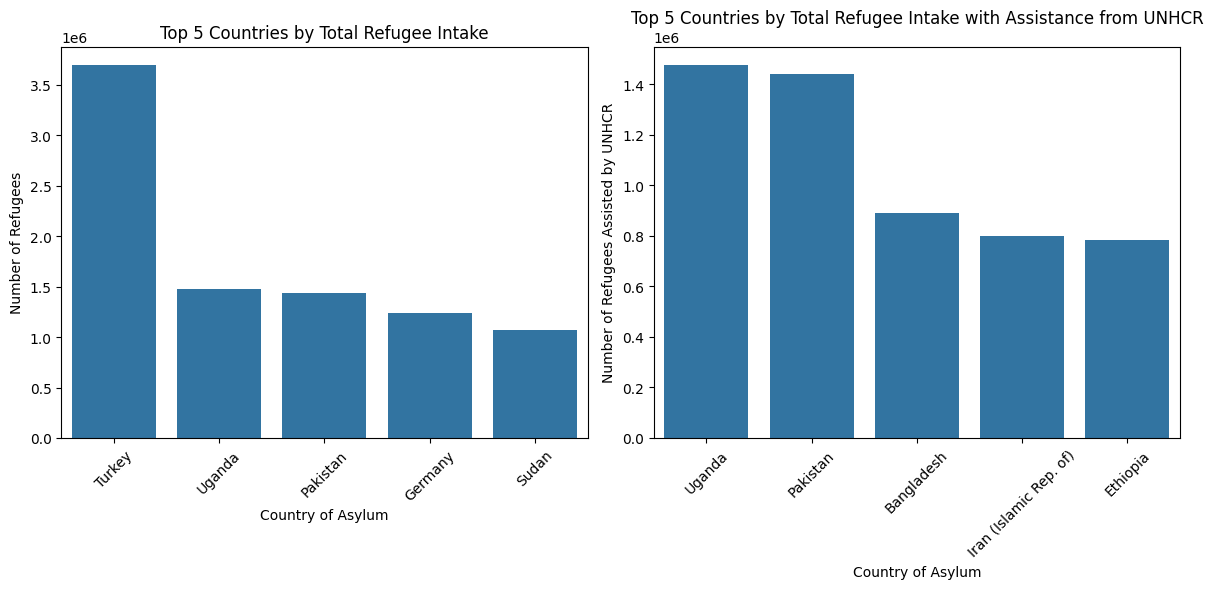

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
top_refugees = (
    df.groupby('country_asylum')['num_refugees'].sum()
    .reset_index()
    .sort_values(by='num_refugees', ascending=False)
    .head(5)
)
top_assistance = (
    df.groupby('country_asylum')['refugees_assisted_by_UNHCR'].sum()
    .reset_index()
    .sort_values(by='refugees_assisted_by_UNHCR', ascending=False)
    .head(5)
)

sns.barplot(
    x='country_asylum', 
    y='num_refugees', 
    data=top_refugees,
    ax=axes[0]
)
axes[0].set_title('Top 5 Countries by Total Refugee Intake')
axes[0].set_xlabel('Country of Asylum')
axes[0].set_ylabel('Number of Refugees')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    x='country_asylum', 
    y='refugees_assisted_by_UNHCR', 
    data=top_assistance,
    ax=axes[1]
)
axes[1].set_title('Top 5 Countries by Total Refugee Intake with Assistance from UNHCR')
axes[1].set_xlabel('Country of Asylum')
axes[1].set_ylabel('Number of Refugees Assisted by UNHCR')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [47]:
fig = px.choropleth(top_10_countries, locations='country_asylum', locationmode='country names',
                    color='num_refugees', title='Top 10 Countries by Total Refugee Intake')
fig.show()

In [30]:
df_grouped = (
    df.groupby('country_asylum')[['num_refugees', 'refugees_assisted_by_UNHCR']]
    .sum()
    .reset_index()
    .sort_values(by='num_refugees', ascending=False)
    .head(5)
)

In [31]:
df_melted = df_grouped.melt(
    id_vars='country_asylum', 
    var_name='Category', 
    value_name='count'
)

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='country_asylum', 
    y='count', 
    data= df_melted,
    hue="Category"
)
plt.title('Top 5 Asylum Countries: Refugees vs Assisted by UNHCR')
plt.xlabel('Country of Asylum')
plt.ylabel('Number of Refugees and Assistance')
plt.xticks(rotation=45)
plt.show()

In [49]:
top_spenders = (
    df.groupby('country_asylum')['host_country_administration_cost'].sum()
    .reset_index()
    .sort_values(by='host_country_administration_cost', ascending=False)
    .head(5)
)
top_spenders['host_country_administration_cost'] = top_spenders['host_country_administration_cost'] / 1e6  # Convert to millions
top_spenders

,country_asylum,host_country_administration_cost
148,Turkey,73936.62
151,Uganda,29506.22
113,Pakistan,28770.46
58,Germany,24703.20
138,Sudan,21366.78


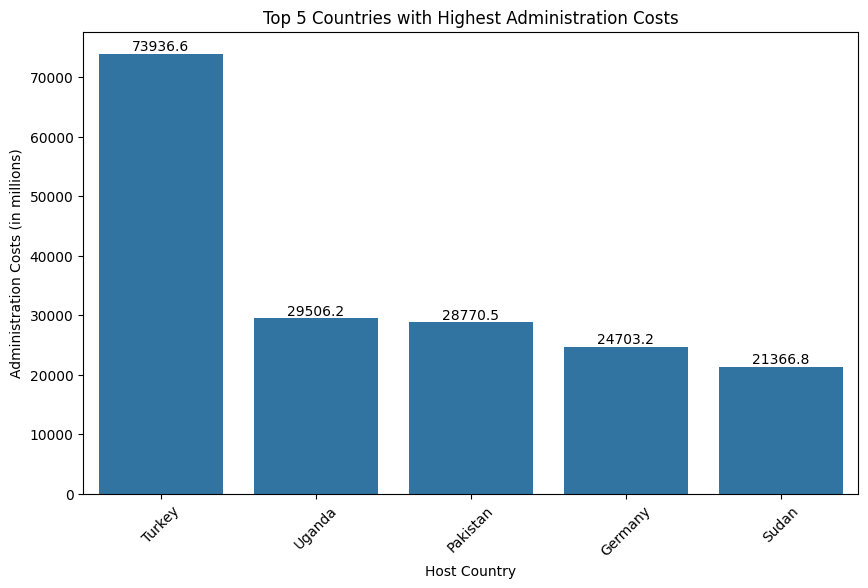

In [50]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='country_asylum', 
    y='host_country_administration_cost', 
    data=top_spenders
)
ax.bar_label(ax.containers[0])
plt.title('Top 5 Countries with Highest Administration Costs')
plt.xlabel('Host Country')
plt.ylabel('Administration Costs (in millions)')
plt.xticks(rotation=45)
plt.show()

Findings:
- Turkey leads with over 73 billion in administration costs, followed by Uganda, etc
- These countries are known for hosting large refugee populations.


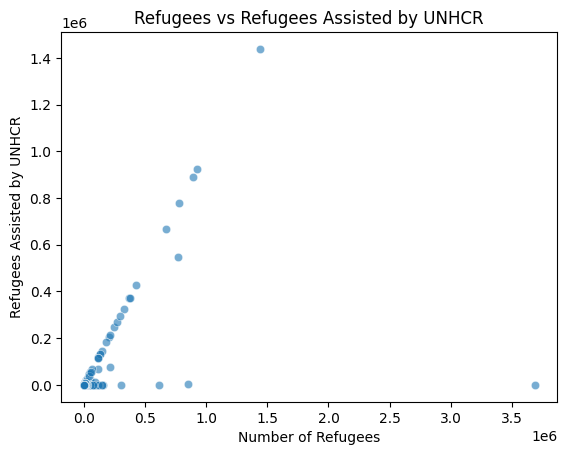

In [71]:
sns.scatterplot(data=df, x='num_refugees', y='refugees_assisted_by_UNHCR', alpha=0.6)
plt.title('Refugees vs Refugees Assisted by UNHCR')
plt.xlabel('Number of Refugees')
plt.ylabel('Refugees Assisted by UNHCR')
plt.show();

In [ ]:
"""
Refugees Assisted by UNHCR vs Host Country Administration Cost
"""
assisted = df.groupby('country_asylum')['refugees_assisted_by_UNHCR'].sum().reset_index()

costs = df.groupby('country_asylum')['host_country_administration_cost'].sum().reset_index()

merged = pd.merge(assisted, costs, on='country_asylum')
merged['cost_per_assisted'] = merged['host_country_administration_cost'] / merged['refugees_assisted_by_UNHCR']
merged['cost_per_assisted'].replace([np.inf, -np.inf], 0, inplace=True)



In [ ]:
# top 10 countries by cost per assisted refugee
merged.sort_values(by='cost_per_assisted', ascending=False).head(10)


,country_asylum,refugees_assisted_by_UNHCR,host_country_administration_cost,cost_per_assisted
25,Canada,5,2508540000,5.017080e+08
69,Indonesia,8,201520000,2.519000e+07
20,Bulgaria,22,435400000,1.979091e+07
30,China,323,6068600000,1.878824e+07
0,Afghanistan,161,1444520000,8.972174e+06
83,Lebanon,2240,17135160000,7.649625e+06
72,Ireland,27,188420000,6.978519e+06
92,Malaysia,519,2599040000,5.007784e+06
22,Burundi,308,1536740000,4.989416e+06
62,Guinea,29,124780000,4.302759e+06


<Axes: title={'center': 'Top 10 Countries by Cost per Assisted Refugee'}, xlabel='country_asylum'>

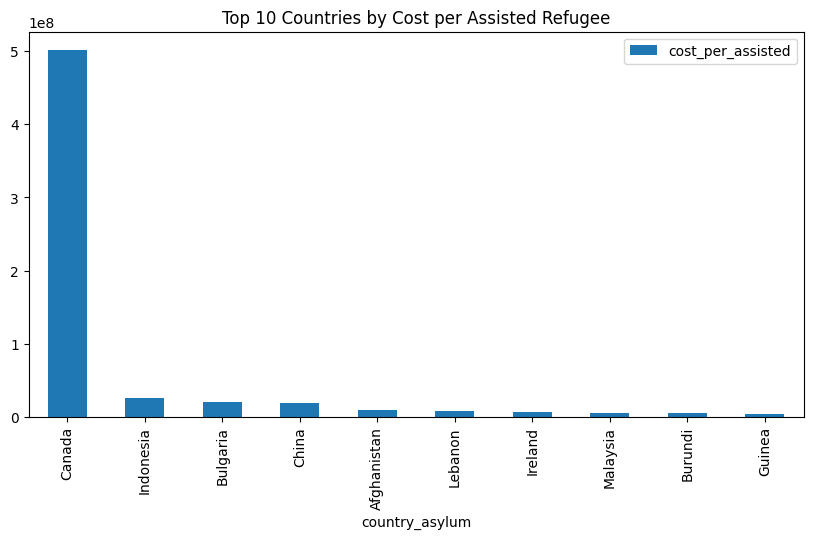

In [63]:
merged.sort_values(by='cost_per_assisted', ascending=False).head(10).plot(
    kind='bar', x='country_asylum', y='cost_per_assisted',
    title='Top 10 Countries by Cost per Assisted Refugee', figsize=(10, 5)
)


### Findings:
- Canada has the highest cost per assisted refugee, nearly 500 million units (likely in local currency or USD).
- Other countries like Indonesia, Bulgaria, China, and Afghanistan have significantly lower costs.
- The disparity is stark, indiccating there could be outliers.


Text(0.5, 0, 'Refugees Assisted by UNHCR')

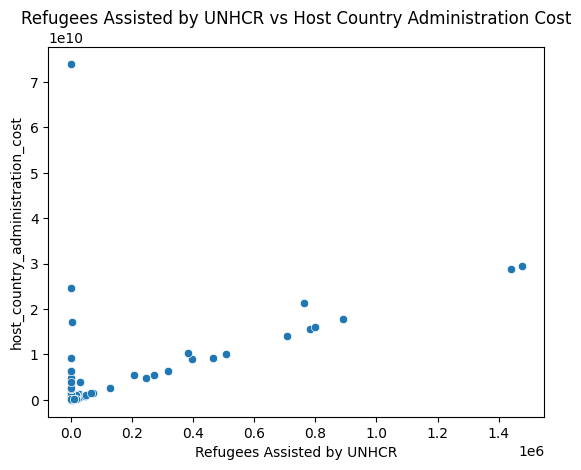

In [ ]:
sns.scatterplot(data=merged, x='refugees_assisted_by_UNHCR', y='host_country_administration_cost')
plt.title('Refugees Assisted by UNHCR vs Host Country Administration Cost')
plt.xlabel('Refugees Assisted by UNHCR')

### Findings: 
- This visual showa a clear positive correlation, as the number of refugees assisted increases, so does administration cost.
- This confirms that cost scales with volume, but not always proportionally.

# Insights and Recommendations 

### Insights
- Countries assisting more refugees tend to spend more—but some do so more efficiently than others.
- Nations like Turkey and Uganda bear a significant financial burden in managing refugee support. this high total cost doesn’t necessarily mean inefficiency, however it could reflect large refugee intake, long-term hosting or complex administrative systems
- The analysis revealed that Cost per assisted refugee varies dramatically across countries.
- High cost could indicate that the country spend more comprehensive services, e.g., housing, healthcare, legal aid, higher operational expenses or smaller refugee populations,which inflates per capita cost.
- on the other hand, countries with lower costs may be more efficient, receiving external aid or providing minimal services

### Recommendations
- Since Efficiency ≠ Spending Less, It might be about spending wisely per refugee. Therfore;
- Policy Implications: 
    - Countries like Turkey and Uganda may need financial reinforcement, while countries like Canada could explore cost optimization.
- For Global Policy and Research
    - Expand data coverage beyond 2021 to track trends over time, e.g., conflict resolution, resettlement success.
    - Explore per capita refugee ratios or cost per refugee for fairer comparisons between large and small nations.
    - Integrate socio-economic indicators,e.g., GDP, unemployment rate, to better understand how local capacity affects refugee absorption

- For Future Analysis or model development
    - Address feature redundancy by applying Principal Component Analysis (PCA) or feature selection.
    - Visualize geospatial patterns,using choropleth maps, to reveal regional concentration and migration corridors.
    - If longitudinal data becomes available, perform time-series analysis to forecast refugee trends and budgetary needs.
